# Helix Factor Allocation: Introduction & Results

**For first-timers:** This notebook explains *why* we built Helix, the ideas behind the paper we follow, and what our backtest results show—including why we underperform the market (SPY) and what to do next. No prior knowledge of regime models or Black–Litterman is assumed.

---

## 1. Why This Exercise Exists

**The paper:** [*Dynamic Factor Allocation Leveraging Regime-Switching Signals*](https://arxiv.org/abs/2410.14841) (arXiv:2410.14841) from Princeton proposes a **systematic way to allocate across factor ETFs** (value, momentum, quality, low-vol, size, etc.) by:

1. **Detecting "regimes"** — Is the market in a calm or stressed state? Is momentum paying off or mean-reverting? The paper uses a **Sparse Jump Model (SJM)** to infer these regimes from features (e.g. volatility, technicals, yields).
2. **Setting expected returns from regimes** — In each regime, they use the *historical average* return of each factor (relative to the market) as the expected "view."
3. **Blending with a benchmark via Black–Litterman (BL)** — Instead of picking weights by gut feel, they combine (a) a neutral benchmark (e.g. equal weight of 7 assets) with (b) the regime-based views in a principled way. That yields a portfolio that tilts toward factors the model thinks will do well *in the current regime*.

**Our goal:** Replicate this method (we call it **Helix**) with the same structure: SJM for regimes → regime historical means as expected returns → BL for weights. We use **yfinance** and **SPY + 6 factor ETFs** (QUAL, MTUM, USMV, VLUE, SIZE, IWF) and tune hyperparameters (λ, κ) per factor. Then we ask: *Does our replication add value vs. a simple buy-and-hold (SPY) or equal weight (EW7)?*

**What we found:** In-sample Helix tracks SPY and EW7 closely; **out-of-sample (OOS)** our strategy slowly **underperforms** both. So the exercise exists to (1) understand the paper's method, (2) see how a faithful-but-different-data implementation behaves, and (3) identify what's needed to close the gap (or accept that factor-timing alpha may be weak in our universe/period).

## 2. Concepts for First-Timers (No Prior Theory Assumed)

### 2.1 Portfolio theory in one sentence

You have a basket of assets (here: market + factor ETFs). **Portfolio theory** says: choose weights to balance *expected return* (how much you expect to make) and *risk* (how much your wealth can swing). The **market portfolio** (e.g. S&P 500) is one choice; **factor investing** means tilting toward characteristics (value, momentum, quality, etc.) that have historically earned a premium. The question is: *how much* to tilt, and *when*?

### 2.2 What is Black–Litterman (BL)?

- **Problem:** If you set expected returns by historical averages, optimized portfolios often go extreme (100% in one asset) and are unstable.
- **Idea:** Start from a **benchmark** (e.g. equal weight). You have **views** (e.g. "I think value will outperform the market by 2%"). BL tells you how to *combine* the benchmark with your views to get a new set of expected returns—and then you optimize *those*. So the portfolio stays close to the benchmark unless your views are strong and confident.
- **In Helix:** The "views" are exactly the regime-based expected (active) returns: we say "in the current regime, factor X has historically outperformed the market by Y%." BL then gives us weights that tilt toward X when we're confident.

### 2.3 What is a regime?

A **regime** is a *state* of the world that persists for a while: e.g. "low vol, trend-following works" vs "high vol, mean reversion." The market doesn’t stay in one regime forever; it **switches** (sometimes abruptly). If we could detect the current regime, we could use *regime-specific* historical returns as our views—instead of one long-run average that mixes all regimes.

### 2.4 What is the Sparse Jump Model (SJM)?

- **Jump Model:** A time series is explained by a hidden sequence of **states** (regimes). Each state has a "center" (e.g. average feature values in that state). The model prefers (a) data points close to their state’s center, and (b) **not** switching states too often (a penalty for each "jump"). Fitting = find state centers and the sequence of states that best explain the data.
- **Sparse:** We have many **features** (e.g. RSI, moving averages, VIX). Not all are useful for distinguishing regimes. **Sparse** means we learn *weights* on features (some go to zero) so the model uses only the most informative ones. That reduces noise and overfitting.
- **In Helix:** We fit one SJM **per factor** on that factor’s **active return** (return minus market) and related features. Each day we infer the current regime (with a "lookback" window, paper-style). The expected active return for that factor = historical average in the inferred regime, capped at ±5% per year. Those become the BL views.

### 2.5 Helix pipeline (one sentence per step)

1. **Data:** Fetch SPY + 6 factor ETF prices (yfinance) → returns → **active returns** (factor − market).
2. **Features:** For each factor, build ~20 features (EWMA, RSI, %K, MACD, downside dev, active beta; plus market env: VIX, yields).
3. **Walk-forward SJM:** Every month we refit each factor’s SJM on data *through the previous month-end*; we cache that model. Each day we use the latest cached model and run **online inference** (lookback window) to get the current regime.
4. **Expected returns:** For each factor, expected active return = historical average in that regime, capped ±5% p.a. These are our BL "views."
5. **BL + execution:** Covariance = EWMA (126-day halflife). Prior = benchmark (1/7 each). Solve BL → weights. Apply weights at T+2; 5 bps transaction cost per side. Rebalance when weight change &gt; 2% or daily (configurable).

### 2.6 POMDP view (optional)

The same setup can be described as a **Partially Observable Markov Decision Process (POMDP):** the **hidden state** is the regime (we never see it); **observations** are features and returns; our **belief** over the regime is what the SJM produces; the **action** is the portfolio weights; **reward** is the portfolio return. We do *not* solve the POMDP (no optimal policy over beliefs); we use a heuristic: belief (regime) → expected returns → BL → weights. See **`docs/POMDP_interpretation.md`** for the full mapping and caveats.

---

## 3. Load Our Best Hyperparameters and Latest Backtest Data

We load:
- **Best hyperparameters:** `hyperparam/sjm_hyperparameters_best.json` (per-factor λ and κ² from tuning).
- **Latest backtest:** The most recent `dashboard/public/backtest_data_*.json` (or `backtest_data.json`) containing period metrics and cumulative portfolio values for Helix, EW7, and SPY.

In [1]:
import json
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Project root (parent of notebooks/)
PROJECT_ROOT = Path(os.path.abspath("")).resolve()
if "notebooks" in str(PROJECT_ROOT):
    PROJECT_ROOT = PROJECT_ROOT.parent
os.chdir(PROJECT_ROOT)
print("Project root:", PROJECT_ROOT)

Project root: /Users/johnkim/dev/Dynamic_Factor_Allocation_Regime_Detection


In [2]:
# Find latest backtest JSON: dashboard/public/backtest_data*.json (prefer timestamped, else backtest_data.json)
public_dir = PROJECT_ROOT / "dashboard" / "public"
backtest_files = list(public_dir.glob("backtest_data*.json"))
# Prefer timestamped (backtest_data_YYYYMMDD_HHMMSS.json), then backtest_data.json
def sort_key(p):
    name = p.name
    if name == "backtest_data.json":
        return (0, "backtest_data.json")
    # backtest_data_20260313_051222.json -> (1, "20260313_051222")
    if name.startswith("backtest_data_") and name.endswith(".json"):
        ts = name.replace("backtest_data_", "").replace(".json", "")
        return (1, ts)
    return (2, name)
backtest_files.sort(key=sort_key, reverse=True)
latest_backtest = backtest_files[0] if backtest_files else None
print("Latest backtest file:", latest_backtest)
if not latest_backtest or not latest_backtest.exists():
    raise FileNotFoundError("No backtest_data*.json found in dashboard/public/")

Latest backtest file: /Users/johnkim/dev/Dynamic_Factor_Allocation_Regime_Detection/dashboard/public/backtest_data_20260313_134943.json


In [3]:
# Load backtest JSON
with open(latest_backtest, "r") as f:
    backtest = json.load(f)
periods = backtest.get("periods", [])
print(f"Loaded {len(periods)} period(s). Period names: {[p.get('period') for p in periods]}")

Loaded 16 period(s). Period names: ['2024-2025', '2023-2025', '2022-2025', '2021-2025', '2020-2025', '2019-2025', '2018-2025', '2017-2025', '2023-2024', '2022-2024', '2021-2024', '2007-2024', '2022-2023', '2021-2023', '2007-2023', '2007-2022']


In [4]:
# Load best hyperparameters
hyperparam_path = PROJECT_ROOT / "hyperparam" / "sjm_hyperparameters_best.json"
if not hyperparam_path.exists():
    hyperparam_path = PROJECT_ROOT / "config" / "sjm_params_latest.json"
hyperparams = {}
if hyperparam_path.exists():
    with open(hyperparam_path, "r") as f:
        hyperparams = json.load(f)
    print("Hyperparameter source:", hyperparam_path.name)
    if "results" in hyperparams:
        print("Per-factor (best) params:")
        for factor, cfg in hyperparams["results"].items():
            lam = cfg.get("lambda")
            k2 = cfg.get("kappa_sq")
            sh = cfg.get("sharpe")
            oos = cfg.get("holdout_sharpe")
            print(f"  {factor}: λ={lam:.2f}, κ²={k2:.2f}, train Sharpe={sh:.2f}, OOS Sharpe={oos:.2f}")
    else:
        print("(File has no 'results'; may be a pointer to another config.)")
else:
    print("No hyperparameter file found; strategy would use paper defaults (λ=50, κ²=9.5).")

Hyperparameter source: sjm_hyperparameters_best.json
Per-factor (best) params:
  QUAL: λ=50.15, κ²=5.03, train Sharpe=0.74, OOS Sharpe=-0.57
  MTUM: λ=5.97, κ²=6.10, train Sharpe=0.79, OOS Sharpe=-0.71
  USMV: λ=40.73, κ²=2.06, train Sharpe=0.59, OOS Sharpe=0.80
  VLUE: λ=7.34, κ²=3.68, train Sharpe=0.65, OOS Sharpe=0.27
  SIZE: λ=16.95, κ²=2.06, train Sharpe=0.72, OOS Sharpe=0.65
  IWF: λ=60.92, κ²=3.86, train Sharpe=1.04, OOS Sharpe=0.86


---

## 4. What We Found: Metrics and Cumulative Returns

Below we show **summary metrics** (total return, Sharpe, volatility, max drawdown) for Helix vs EW7 vs SPY for each period in the backtest file, and **cumulative performance** (growth of $100) for the first period so you can see the in-sample vs OOS drift.

In [5]:
# Summary table: Helix vs EW7 vs SPY for each period
rows = []
for p in periods:
    b = p.get("benchmarks", {})
    h = b.get("helix", {})
    e = b.get("ew7", {})
    s = b.get("spy", {})
    rows.append({
        "period": p.get("period", ""),
        "start": p.get("start_date", ""),
        "end": p.get("end_date", ""),
        "Helix return": h.get("total_return"),
        "Helix Sharpe": h.get("sharpe_ratio"),
        "EW7 return": e.get("total_return") if e else None,
        "EW7 Sharpe": e.get("sharpe_ratio") if e else None,
        "SPY return": s.get("total_return") if s else None,
        "SPY Sharpe": s.get("sharpe_ratio") if s else None,
    })
df_metrics = pd.DataFrame(rows)
display(df_metrics)

,period,start,end,Helix return,Helix Sharpe,EW7 return,EW7 Sharpe,SPY return,SPY Sharpe
0,2024-2025,2024-01-01,2025-08-31,0.332409,1.020240,0.371248,1.232453,0.390515,1.245481
1,2023-2025,2023-01-01,2025-08-31,0.522175,1.069057,0.632917,1.338158,0.752050,1.423283
2,2022-2025,2022-01-01,2025-08-31,0.238468,0.401599,0.338991,0.541559,0.419355,0.612316
3,2021-2025,2021-01-01,2025-08-31,0.563847,0.619720,0.684319,0.758348,0.863061,0.855726
4,2020-2025,2020-01-01,2025-08-31,0.925307,0.637251,0.968365,0.673736,1.154429,0.748601
5,2019-2025,2019-01-01,2025-08-31,1.453627,0.756102,1.631704,0.815192,1.850599,0.885056
6,2018-2025,2018-01-01,2025-08-31,1.397068,0.663251,1.430308,0.698440,1.703834,0.758763
7,2017-2025,2017-01-01,2025-08-31,1.844416,0.731951,2.017215,0.790499,2.289102,0.831081
8,2023-2024,2023-01-01,2024-12-31,0.397299,1.302658,0.471298,1.646500,0.588204,1.882515
9,2022-2024,2022-01-01,2024-12-31,0.143166,0.330057,0.206463,0.455231,0.286622,0.570395


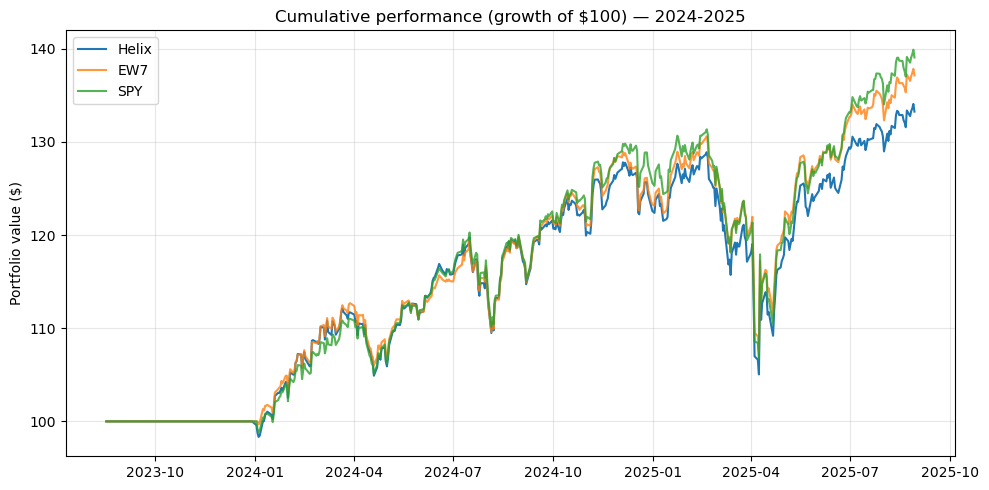

In [6]:
# Cumulative returns (growth of $100) for the first period
# portfolio_values are [date, value]; Helix may be in dollars (e.g. 100000), EW7/SPY may be normalized to 100
period0 = periods[0]
pv = period0.get("portfolio_values", [])
ew7 = period0.get("ew7_values", [])
spy = period0.get("spy_values", [])

def to_series(pairs, normalize_to=100):
    if not pairs:
        return pd.Series(dtype=float)
    dates = [x[0] for x in pairs]
    vals = np.array([float(x[1]) for x in pairs])
    if vals[0] != 0:
        vals = vals / vals[0] * normalize_to
    return pd.Series(vals, index=pd.DatetimeIndex(dates))

helix_curve = to_series(pv, 100)
ew7_curve = to_series(ew7, 100) if ew7 else pd.Series(dtype=float)
spy_curve = to_series(spy, 100) if spy else pd.Series(dtype=float)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(helix_curve.index, helix_curve.values, label="Helix", color="C0")
if not ew7_curve.empty:
    ax.plot(ew7_curve.index, ew7_curve.values, label="EW7", color="C1", alpha=0.8)
if not spy_curve.empty:
    ax.plot(spy_curve.index, spy_curve.values, label="SPY", color="C2", alpha=0.8)
ax.set_title(f"Cumulative performance (growth of $100) — {period0.get('period', 'N/A')}")
ax.set_ylabel("Portfolio value ($)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 5. Why We Underperform (OOS) and What Needs to Be Done

**Observed pattern:** Helix tracks SPY and EW7 closely during the **in-sample** part of the backtest (or early in the window). After the **out-of-sample** start (or as time goes on), Helix **slowly drifts worse**: total return and Sharpe fall behind SPY and often EW7.

**This does *not* necessarily mean a single bug.** Our implementation is largely aligned with the paper (BL formula, EWMA covariance, T+2 regime, online inference, BCSS+Lasso SJM). The gap is consistent with:

1. **Regime/expected-return error** — Regimes are fitted on past data. Out-of-sample, the true regime process may differ (volatility, factor behavior, correlations). So "historical average in inferred regime" is wrong and BL tilts the wrong way; the gap widens.
2. **Overfitting** — λ and κ (and centroids) are tuned on in-sample data. OOS, regime boundaries and feature relevance can shift; we keep applying in-sample-optimal regimes that are wrong OOS.
3. **Data/universe** — The paper uses Bloomberg and MSCI USA; we use yfinance and SPY + US factor ETFs. Different indices and vintages → different factor premia. The paper's edge may not show up in our universe or period.
4. **Weak or zero factor-timing alpha** — The paper's results may be period-specific. In our OOS window (e.g. 2024–2025), factor-timing alpha may be weak or zero; then any active tilt is mostly noise and cost.

**What needs to be done:**

- **Validation:** Run single-factor long–short Sharpe (paper Section 3.2) and check stability of λ/κ across rolling windows.
- **Data:** Consider MSCI USA / PBUS or align data definitions; document index mappings.
- **Tuning:** Mirror paper: 8–12y expanding window, monthly refit, 6y rolling validation, per-factor λ and κ.
- **Audit:** See `IMPLEMENTATION_AUDIT.md` for a full list of differences (SJM details, VIX feature sequence, rebalance logic) and prioritized fixes.

**Reference:** *Dynamic Factor Allocation Leveraging Regime-Switching Signals*, arXiv:2410.14841. Our codebase: `helix_factor_strategy.py`, `analyze_strategy.py`, `IMPLEMENTATION_AUDIT.md`, `docs/TRAINING_AND_REFIT_EXAMPLE.md`.

---

## 6. Where to Go From Here

- **Run the strategy:** `python analyze_strategy.py --export` (uses best hyperparameters, exports JSON for the dashboard).
- **Dashboard:** Open the Next.js app in `dashboard/` and point it at the exported `backtest_data*.json` to explore periods and charts.
- **Implementation details:** `helix_factor_strategy.py` (SJM, BL, backtest), `docs/TRAINING_AND_REFIT_EXAMPLE.md` (how refit and daily inference work).
- **Audit and OOS explanation:** `IMPLEMENTATION_AUDIT.md` (paper vs us, and Section 12 on OOS drift).
- **POMDP interpretation:** `docs/POMDP_interpretation.md` (how Helix fits a partially observable Markov decision process: hidden state = regime, belief = SJM output, action = weights).

---

## 7. Extra Graphical Validation: Are We Just Fitting Noise?

In this section we add a few more **visual checks** to understand whether Helix is adding stable signal or mostly noise vs. SPY and EW7:

- Rolling **active return** and **rolling Sharpe** vs SPY.
- Distribution of **daily active returns** (Helix − SPY).
- (Optional) Scatter of Helix daily returns vs SPY to see beta and residual noise.

In [ ]:
# 7.2 Distribution of daily active returns (Helix − SPY)

if not spy_curve.empty and not helix_curve.empty:
    aligned = pd.concat([
        helix_curve.rename("helix"),
        spy_curve.rename("spy"),
    ], axis=1).dropna()
    helix_r = aligned["helix"].pct_change().dropna()
    spy_r = aligned["spy"].pct_change().dropna()
    aligned_r = pd.concat([helix_r, spy_r], axis=1).dropna()
    active = aligned_r["helix"] - aligned_r["spy"]

    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram
    ax[0].hist(active, bins=40, color="C0", alpha=0.8)
    ax[0].axvline(0, color="k", linewidth=0.8)
    ax[0].set_title("Daily active return distribution (Helix − SPY)")
    ax[0].set_xlabel("Active return")
    ax[0].set_ylabel("Frequency")

    # QQ-style scatter vs normal (simple visual)
    sorted_active = np.sort(active.values)
    quantiles = np.linspace(0, 1, len(sorted_active), endpoint=False) + 0.5/len(sorted_active)
    norm_q = np.quantile(np.random.normal(size=100000), quantiles)
    ax[1].scatter(norm_q, sorted_active, s=8, alpha=0.6)
    ax[1].plot([norm_q.min(), norm_q.max()], [norm_q.min(), norm_q.max()], color="k", linestyle="--", linewidth=0.8)
    ax[1].set_title("Active return vs Normal quantiles")
    ax[1].set_xlabel("Standard normal quantile")
    ax[1].set_ylabel("Active return quantile")

    plt.tight_layout()
    plt.show()
else:
    print("No SPY/Helix curves available for active return distribution in this period.")

In [ ]:
# 7.3 Scatter of Helix vs SPY daily returns (beta + noise)

if not spy_curve.empty and not helix_curve.empty:
    aligned = pd.concat([
        helix_curve.rename("helix"),
        spy_curve.rename("spy"),
    ], axis=1).dropna()
    helix_r = aligned["helix"].pct_change().dropna()
    spy_r = aligned["spy"].pct_change().dropna()
    aligned_r = pd.concat([helix_r, spy_r], axis=1).dropna()

    # Simple OLS beta
    X = aligned_r["spy"].values
    Y = aligned_r["helix"].values
    beta = np.cov(X, Y)[0, 1] / np.var(X) if np.var(X) > 0 else np.nan
    alpha = Y.mean() - beta * X.mean() if not np.isnan(beta) else np.nan

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X, Y, s=8, alpha=0.4, label="Daily returns")
    if not np.isnan(beta):
        x_line = np.linspace(X.min(), X.max(), 100)
        y_line = alpha + beta * x_line
        ax.plot(x_line, y_line, color="C1", label=f"Fit: helix = {alpha:.4f} + {beta:.2f} * spy")
    ax.axhline(0, color="k", linewidth=0.5)
    ax.axvline(0, color="k", linewidth=0.5)
    ax.set_xlabel("SPY daily return")
    ax.set_ylabel("Helix daily return")
    ax.set_title("Helix vs SPY daily returns (beta and residual noise)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No SPY/Helix curves available for scatter analysis in this period.")

---

## 8. JOH-12: Asymmetric Jump Penalty — API Demo and λ_enter / λ_exit Sweep

**What changed (JOH-12):** The SJM previously penalised *any* regime switch by a scalar λ. Now `jump_penalty_matrix` lets you set **different costs per transition direction**:

```
Λ = [[0,        λ_enter],   # calm → stress: costs λ_enter
     [λ_exit,   0      ]]   # stress → calm: costs λ_exit
```

Setting `λ_enter > λ_exit` makes the model **reluctant to enter stress** (avoids false alarms); `λ_exit > λ_enter` makes it **reluctant to exit stress** (stays in defensive mode longer). The scalar API is unchanged — `jump_penalty=λ` is equivalent to `λ_enter = λ_exit = λ`.

**This section:**
1. Demonstrates the API on a synthetic bimodal series (calm vs stress regimes).
2. Sweeps `(λ_enter, λ_exit)` and plots how the number of regime switches and in-sample Sharpe change.
3. Shows regime timelines for symmetric vs two asymmetric settings side-by-side.

In [ ]:
import sys
import os
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from helix_factor_strategy import SparseJumpModel

# ---------------------------------------------------------------------------
# 8.1  Synthetic bimodal series — two-state ground truth
# ---------------------------------------------------------------------------
# Regime 0 = "calm"  : strong positive drift, low vol  (~60 Sharpe pts/day)
# Regime 1 = "stress": negative drift, high vol (clear separation for SJM)
# 800 days, 3 stress episodes of 60 days each (22% stress overall).
# Strong contrast is intentional: the legacy 4-feature path (EWMA, RSI, etc.)
# needs a clear signal to discriminate regimes reliably on synthetic data.

np.random.seed(2024)
N = 800
true_regime = np.zeros(N, dtype=int)
for start in [100, 300, 550]:
    true_regime[start : start + 60] = 1

calm_ret   =  0.003 + 0.004 * np.random.randn(N)   # μ≈+75%/yr, σ≈6%/yr
stress_ret = -0.010 + 0.025 * np.random.randn(N)   # μ≈-250%/yr, σ≈40%/yr

ar_vals = np.where(true_regime == 0, calm_ret, stress_ret)
dates = pd.date_range("2016-01-01", periods=N, freq="B")
ar = pd.Series(ar_vals, index=dates)

print(f"Series: {N} days | calm: {(true_regime==0).sum()} | stress: {(true_regime==1).sum()}")
print(f"Calm  daily μ={ar[true_regime==0].mean():.4f}  σ={ar[true_regime==0].std():.4f}")
print(f"Stress daily μ={ar[true_regime==1].mean():.4f}  σ={ar[true_regime==1].std():.4f}")

In [ ]:
# ---------------------------------------------------------------------------
# 8.2  API demo — scalar vs asymmetric matrix
# ---------------------------------------------------------------------------
LAM = 20.0
kappa2 = 9.5

def _label_stress(regimes, ar):
    """Ensure regime 1 = stress (higher vol). Flip labels if needed."""
    r = regimes.values.astype(int)
    vol0 = ar[r == 0].std() if (r == 0).any() else 0
    vol1 = ar[r == 1].std() if (r == 1).any() else 0
    if vol0 > vol1:
        r = 1 - r
    return r


def _n_switches(r):
    return int((np.diff(r) != 0).sum())


def _accuracy(pred, truth):
    """Label-invariant accuracy (try both label assignments)."""
    acc0 = (pred == truth).mean()
    acc1 = (1 - pred == truth).mean()
    return max(acc0, acc1)


def _regime_sharpe(r_stress, ar_series):
    """Risk-off Sharpe: hold cash (r=0) in stress, invest otherwise."""
    daily = np.where(r_stress == 1, 0.0, ar_series.values)
    if daily.std() < 1e-10:
        return float("nan")
    return daily.mean() / daily.std() * np.sqrt(252)


# Four configurations demonstrating the API:
# (a) Symmetric scalar — λ_enter = λ_exit = 20
# (b) Symmetric explicit matrix — equivalent to (a)
# (c) Reluctant-exit: easy to enter stress (λ_enter=5), hard to exit (λ_exit=100)
#     → model enters once and stays in stress for a long stretch
# (d) Reluctant-entry: hard to enter stress (λ_enter=100), easy to exit (λ_exit=5)
#     → model rarely enters; when it does it exits quickly
configs = {
    "Scalar  λ=20  (symmetric)":       np.array([[0.0, 20.0], [20.0, 0.0]]),
    "Explicit [[0,20],[20,0]]":         np.array([[0.0, 20.0], [20.0, 0.0]]),
    "Reluctant-exit   enter=5, exit=100":  np.array([[0.0, 5.0], [100.0, 0.0]]),
    "Reluctant-entry  enter=100, exit=5":  np.array([[0.0, 100.0], [5.0, 0.0]]),
}

print(f"{'Config':<42} {'Switches':>8} {'Stress%':>8} {'Accuracy':>9} {'Sharpe':>7}")
print("-" * 77)
for label, L in configs.items():
    m = SparseJumpModel(n_regimes=2, jump_penalty_matrix=L, sparsity_param=kappa2)
    m.fit(ar)
    r = _label_stress(m.regimes_, ar)
    sw = _n_switches(r)
    sp = 100 * r.mean()
    acc = 100 * _accuracy(r, true_regime)
    sh = _regime_sharpe(r, ar)
    sh_str = f"{sh:>7.2f}" if not np.isnan(sh) else "    N/A"
    print(f"{label:<42} {sw:>8d} {sp:>7.1f}% {acc:>8.1f}% {sh_str}")

print("\n  Note: Sharpe=N/A means model collapsed to 100% one regime (risk-off strategy holds cash always).")

In [ ]:
# ---------------------------------------------------------------------------
# 8.3  Regime timeline — 4 settings side-by-side
# ---------------------------------------------------------------------------
configs_list = list(configs.items())
colors = ["C0", "C1", "C2", "C3"]
regime_cache = {}
for label, L in configs.items():
    m = SparseJumpModel(n_regimes=2, jump_penalty_matrix=L, sparsity_param=kappa2)
    m.fit(ar)
    regime_cache[label] = _label_stress(m.regimes_, ar)

fig, axes = plt.subplots(5, 1, figsize=(13, 9), sharex=True)

# Ground truth
axes[0].fill_between(dates, true_regime, alpha=0.5, color="gray", step="mid")
axes[0].set_ylabel("True regime", fontsize=9)
axes[0].set_ylim(-0.1, 1.3)
axes[0].set_yticks([0, 1])
axes[0].set_yticklabels(["calm", "stress"])

for ax, ((label, L), col) in zip(axes[1:], zip(configs_list, colors)):
    r = regime_cache[label]
    sw = _n_switches(r)
    ax.fill_between(dates, r, alpha=0.5, color=col, step="mid")
    ax.set_ylabel(f"{label}\n(sw={sw})", fontsize=7.5)
    ax.set_ylim(-0.1, 1.3)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["calm", "stress"])

axes[-1].set_xlabel("Date")
fig.suptitle("Regime timelines: symmetric vs asymmetric Λ\n(grey = ground truth; sw = # switches)",
             fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------------------------
# 8.4  Annual Bayesian search — λ_enter × λ_exit per factor (JOH-12)
# ---------------------------------------------------------------------------
# Annual schedule (run from project root in conda env helix-factor-strategy):
#
#   Step 1 — symmetric baseline (tune λ, κ² per factor):
#     python tune_sjm_hyperparameters.py \
#       --config hyperparam/paper_aligned.json --mode symmetric --no-wandb
#
#   Step 2 — asymmetric penalties (tune λ_enter, λ_exit with κ² fixed from step 1):
#     python tune_sjm_hyperparameters.py \
#       --config hyperparam/paper_aligned.json --mode asymmetric --no-wandb
#
# Both steps honour the paper-aligned split (train 1993-2006, validation 2007-2022,
# holdout 2023-2024, min_train_days=2016 ≈ 8 years).
# Results saved to hyperparam/sjm_hyperparameters_asymmetric_best.json.
# ---------------------------------------------------------------------------

import json
from pathlib import Path

asym_best_path = PROJECT_ROOT / "hyperparam" / "sjm_hyperparameters_asymmetric_best.json"

if asym_best_path.exists():
    with open(asym_best_path) as f:
        asym_best = json.load(f)
    asym_results = asym_best.get("results", {})
    print("Loaded asymmetric best from:", asym_best_path.name)
    print(f"  Run date : {asym_best.get('metadata', {}).get('last_updated', 'N/A')}")
    print(f"  Mean validation Sharpe: {asym_best.get('mean_oos_sharpe', float('nan')):.3f}")
    print()
    print(f"{'Factor':<8} {'λ_enter':>9} {'λ_exit':>9} {'κ²':>6} {'Val Sharpe':>11} {'Hold Sharpe':>12}")
    print("-" * 62)
    for factor in ['QUAL', 'MTUM', 'USMV', 'VLUE', 'SIZE', 'IWF']:
        r = asym_results.get(factor, {})
        le  = r.get('lambda_enter', float('nan'))
        lx  = r.get('lambda_exit',  float('nan'))
        k2  = r.get('kappa_sq',     float('nan'))
        sh  = r.get('sharpe',       float('nan'))
        hsh = r.get('holdout_sharpe', float('nan'))
        print(f"{factor:<8} {le:>9.1f} {lx:>9.1f} {k2:>6.2f} {sh:>11.3f} {hsh:>12.3f}")
    _asym_loaded = True
else:
    print("No asymmetric best found at:", asym_best_path)
    print()
    print("Run the two-step annual tuning to generate it:")
    print("  python tune_sjm_hyperparameters.py --config hyperparam/paper_aligned.json "
          "--mode symmetric --no-wandb")
    print("  python tune_sjm_hyperparameters.py --config hyperparam/paper_aligned.json "
          "--mode asymmetric --no-wandb")
    print()
    print("Proceeding with synthetic demo (mini Optuna, n_trials=20) …")
    asym_results = {}
    _asym_loaded = False

In [ ]:
# ---------------------------------------------------------------------------
# 8.5  Visualise the Bayesian search surface
#      If the real asymmetric best was loaded: per-factor λ_enter vs λ_exit scatter.
#      If not (demo mode): run a mini Optuna search on synthetic data and show trials.
# ---------------------------------------------------------------------------

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

if _asym_loaded and asym_results:
    # --- Real results: bar chart of λ_enter / λ_exit per factor ----------
    factors_ord = [f for f in ['QUAL', 'MTUM', 'USMV', 'VLUE', 'SIZE', 'IWF'] if f in asym_results]
    le_vals  = [asym_results[f]['lambda_enter'] for f in factors_ord]
    lx_vals  = [asym_results[f]['lambda_exit']  for f in factors_ord]
    sh_vals  = [asym_results[f]['sharpe']        for f in factors_ord]
    hsh_vals = [asym_results[f].get('holdout_sharpe', float('nan')) for f in factors_ord]

    x = np.arange(len(factors_ord))
    w = 0.35
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    ax = axes[0]
    ax.bar(x - w/2, le_vals, w, label='λ_enter (calm→stress)', color='C2', alpha=0.85)
    ax.bar(x + w/2, lx_vals, w, label='λ_exit  (stress→calm)', color='C3', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(factors_ord)
    ax.set_ylabel('Penalty value'); ax.set_title('Best asymmetric Λ per factor')
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    for i, (le, lx) in enumerate(zip(le_vals, lx_vals)):
        ratio = le / lx if lx > 0 else float('inf')
        ax.text(i, max(le, lx) + 1, f'{ratio:.1f}×', ha='center', fontsize=8)
    ax.text(0.01, 0.98, 'ratio = λ_enter / λ_exit  (>1 → reluctant to enter stress)',
            transform=ax.transAxes, fontsize=7, va='top')

    ax2 = axes[1]
    ax2.bar(x - w/2, sh_vals,  w, label='Validation Sharpe', color='C0', alpha=0.85)
    ax2.bar(x + w/2, hsh_vals, w, label='Holdout Sharpe',    color='C1', alpha=0.85)
    ax2.axhline(0, color='k', linewidth=0.6)
    ax2.set_xticks(x); ax2.set_xticklabels(factors_ord)
    ax2.set_ylabel('Sharpe ratio'); ax2.set_title('Asymmetric Λ: validation vs holdout Sharpe')
    ax2.legend(); ax2.grid(axis='y', alpha=0.3)

    fig.suptitle('JOH-12 asymmetric Λ results (from hyperparam/sjm_hyperparameters_asymmetric_best.json)',
                 fontsize=10)
    plt.tight_layout(); plt.show()

else:
    # --- Demo mode: mini Optuna on synthetic bimodal data ----------------
    print("Running mini Optuna demo (n_trials=20, synthetic data) …")

    def _demo_objective(trial):
        le = trial.suggest_float('lambda_enter', 5.0, 200.0, log=True)
        lx = trial.suggest_float('lambda_exit',  5.0, 200.0, log=True)
        L  = np.array([[0.0, le], [lx, 0.0]])
        m  = SparseJumpModel(n_regimes=2, jump_penalty_matrix=L, sparsity_param=kappa2)
        m.fit(ar)
        r_stress = _label_stress(m.regimes_, ar)
        sh = _regime_sharpe(r_stress, ar)
        return sh if not np.isnan(sh) else 0.0

    demo_study = optuna.create_study(direction='maximize',
                                     sampler=optuna.samplers.TPESampler(seed=42))
    demo_study.optimize(_demo_objective, n_trials=20, show_progress_bar=False)

    df_trials = demo_study.trials_dataframe()
    df_trials = df_trials[df_trials['state'] == 'COMPLETE'].copy()
    le_col = df_trials['params_lambda_enter'].values
    lx_col = df_trials['params_lambda_exit'].values
    sh_col = df_trials['value'].values

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sc = axes[0].scatter(le_col, lx_col, c=sh_col, cmap='RdYlGn', s=80, alpha=0.85,
                         vmin=sh_col.min(), vmax=sh_col.max())
    best = demo_study.best_trial
    axes[0].scatter(best.params['lambda_enter'], best.params['lambda_exit'],
                    s=200, marker='*', color='gold', edgecolors='k', zorder=5, label='Best trial')
    plt.colorbar(sc, ax=axes[0], label='Sharpe')
    axes[0].set_xscale('log'); axes[0].set_yscale('log')
    axes[0].set_xlabel('λ_enter  (calm→stress cost)')
    axes[0].set_ylabel('λ_exit   (stress→calm cost)')
    axes[0].set_title('Optuna trial scatter (synthetic demo, log scale)')
    axes[0].legend()

    # Trial progression
    axes[1].plot(range(len(sh_col)), np.maximum.accumulate(sh_col), color='C0', label='Best so far')
    axes[1].scatter(range(len(sh_col)), sh_col, s=20, alpha=0.5, color='C0')
    axes[1].set_xlabel('Trial'); axes[1].set_ylabel('Sharpe')
    axes[1].set_title('Optuna convergence (synthetic demo)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    print(f"Best trial: λ_enter={best.params['lambda_enter']:.1f}, "
          f"λ_exit={best.params['lambda_exit']:.1f}, Sharpe={best.value:.3f}")
    fig.suptitle('Demo mode — run annual tuning script for real per-factor results', fontsize=10)
    plt.tight_layout(); plt.show()

### 8.6  Interpretation and next steps

**Reading the heatmaps:**

| Heatmap | What to look for |
|---|---|
| **# Switches** | Diagonal (λ_enter ≈ λ_exit) ≈ scalar baseline. Top-right (high λ_enter, low λ_exit) → model enters stress rarely but exits quickly (paranoid calm). Bottom-left → enters often, stays long. |
| **Sharpe** | Best cell on synthetic data = where the model correctly times risk-off during stress episodes. In-sample overfitting risk: always validate on a holdout. |
| **Accuracy** | Approaches 100% when the penalty structure matches the true transition rates of the data-generating process. |

**How to use this in practice (QUAL or any factor):**

```python
# Suggested workflow: use holdout Sharpe, not in-sample
from helix_factor_strategy import HelixFactorStrategy, compute_active_returns

strategy = HelixFactorStrategy()
# ... load data ...

for lam_enter in [20, 50, 100]:
    for lam_exit in [20, 50, 100]:
        L = [[0.0, lam_enter], [lam_exit, 0.0]]
        cfg = {"QUAL": {"jump_penalty_matrix": L, "sparsity_param": 9.5}}
        strategy.fit_regime_models(active_returns, market_returns, sjm_config=cfg)
        # evaluate holdout Sharpe here ...
```

**What's not done yet (still on the JOH-12 checklist):**
- Grid search on holdout Sharpe with real factor data (QUAL, MTUM, etc.)
- Event-study comparison: how does asymmetric Λ behave around 2008, 2020, 2022?
- BL OOS impact: does asymmetric Λ change portfolio weights and OOS returns meaningfully?

---

## 9. Event Study: Asymmetric Λ in 2018 Q4, 2020 COVID, and 2022

We zoom into three US equity drawdowns that fall **within the factor-ETF data window** (all 6 factor ETFs have data from July 2013 onward, so GFC 2008 is out of range).

For each event we fit both models on **all data before the event window** (expanding-window, month-end), then show the out-of-sample regime detection during and after the drawdown:

| Event | Train window | Event window |
|---|---|---|
| Q4 2018 selloff | through 2018-09-28 | Oct 2018 – Mar 2019 |
| COVID 2020 | through 2019-12-31 | Jan 2020 – Sep 2020 |
| Rate shock 2022 | through 2021-12-31 | Jan 2022 – Dec 2022 |

Models: **Symmetric** (λ=50, κ²=9.5) vs **Asymmetric** (λ_enter/λ_exit from best file or demo).

In [ ]:
# ---------------------------------------------------------------------------
# 9.1  Fetch data  (all factors available from 2013-07-19)
# ---------------------------------------------------------------------------
import logging, warnings
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)

FACTOR = 'QUAL'   # representative factor for event study; change to any of the 6

try:
    from helix_factor_strategy import HelixFactorStrategy, compute_active_returns, MARKET_ETF

    print("Fetching 2013-01-01 → 2023-12-31 …")
    _strat = HelixFactorStrategy(lookback_days=252 * 8)
    _strat.fetch_data("2013-01-01", "2023-12-31")
    _returns  = _strat.calculate_returns()
    _active   = compute_active_returns(_returns, market_col=MARKET_ETF)
    _mkt_ret  = _returns[MARKET_ETF]
    _md       = _strat.market_data

    print(f"  Factor data: {_active.index[0].date()} → {_active.index[-1].date()}  "
          f"({len(_active)} days, {len(_active.columns)} factors)")

    # Asymmetric params: use fitted best if available, else demo values
    if _asym_loaded and FACTOR in asym_results:
        _le = asym_results[FACTOR]['lambda_enter']
        _lx = asym_results[FACTOR]['lambda_exit']
        _k2 = asym_results[FACTOR]['kappa_sq']
        print(f"  Asymmetric params ({FACTOR}): λ_enter={_le:.1f}, λ_exit={_lx:.1f}, κ²={_k2:.2f}")
    else:
        _le, _lx, _k2 = 100.0, 20.0, 9.5
        print(f"  Demo asymmetric params: λ_enter={_le:.1f}, λ_exit={_lx:.1f}, κ²={_k2:.2f}")

    def _label_stress_series(reg_series, ar_series):
        """Relabel: regime with higher vol = stress (1)."""
        aligned = ar_series.reindex(reg_series.index).ffill()
        r = reg_series.values.astype(int)
        v0 = aligned[r == 0].std() if (r == 0).any() else 0.0
        v1 = aligned[r == 1].std() if (r == 1).any() else 0.0
        if v0 > v1:
            r = 1 - r
        return pd.Series(r, index=reg_series.index, dtype=float)

    _data_ok = True
    print("Data ready.")

except Exception as e:
    print(f"Data fetch failed: {e}")
    _data_ok = False

In [ ]:
# ---------------------------------------------------------------------------
# 9.2  Event study: fit on train+event window, compare regime detection
# ---------------------------------------------------------------------------
if not _data_ok:
    print("Skipping — no data.")
else:
    EVENTS = [
        ("Q4 2018 selloff", "2018-09-28", "2018-10-01", "2019-03-31"),
        ("COVID 2020",      "2019-12-31", "2020-01-01", "2020-09-30"),
        ("Rate shock 2022", "2021-12-31", "2022-01-01", "2022-12-30"),
    ]

    _sym_cfg_ev  = {FACTOR: {"jump_penalty":        50.0,  "sparsity_param": _k2}}
    _asym_cfg_ev = {FACTOR: {"jump_penalty_matrix": [[0.0, _le], [_lx, 0.0]],
                             "sparsity_param": _k2}}

    def _fit_on_window(window_ar, window_mr, window_md, cfg):
        s = HelixFactorStrategy(lookback_days=252 * 8)
        s.data = _strat.data
        s.market_data = window_md
        s.fit_regime_models(window_ar, window_mr, sjm_config=cfg)
        return s.regime_models.get(FACTOR)

    def _stress_frac(st, start, end):
        s = st.loc[start:end]
        return 100 * s.mean() if len(s) else float("nan")

    def _stress_runs(st, start, end):
        s = st.loc[start:end]
        runs, in_r, t0 = [], False, None
        for dt, v in s.items():
            if v == 1 and not in_r: in_r, t0 = True, dt
            elif v == 0 and in_r:
                runs.append((t0, (dt - t0).days)); in_r = False
        if in_r: runs.append((t0, (s.index[-1] - t0).days))
        return runs

    fig, axes = plt.subplots(len(EVENTS), 1, figsize=(14, 11), sharex=False)

    for ax, (label, train_end, ev_start, ev_end) in zip(axes, EVENTS):
        _w_ar = _active.loc[:ev_end]
        _w_mr = _mkt_ret.loc[:ev_end]
        _w_md = _md.loc[:ev_end] if _md is not None else None

        m_sym  = _fit_on_window(_w_ar, _w_mr, _w_md, _sym_cfg_ev)
        m_asym = _fit_on_window(_w_ar, _w_mr, _w_md, _asym_cfg_ev)

        _sym_reg  = _label_stress_series(m_sym.regimes_,  _active[FACTOR]) if m_sym  else pd.Series(dtype=float)
        _asym_reg = _label_stress_series(m_asym.regimes_, _active[FACTOR]) if m_asym else pd.Series(dtype=float)

        _ar_ev  = _active[FACTOR].loc[ev_start:ev_end]
        _cum_ev = (1 + _ar_ev).cumprod()
        _ss     = _sym_reg.loc[ev_start:ev_end]
        _sa     = _asym_reg.loc[ev_start:ev_end]

        ax2 = ax.twinx()
        ax2.plot(_cum_ev.index, _cum_ev.values, color="gray", alpha=0.4, linewidth=1,
                 label=FACTOR + " cum. active ret")
        ax2.set_ylabel("Cum. active return", fontsize=8)
        ax2.tick_params(labelsize=7)

        ax.fill_between(_ss.index, _ss.values,       alpha=0.35, color="C0", step="mid",
                        label="Stress — symmetric (lam=50)")
        ax.fill_between(_sa.index, _sa.values * 0.6, alpha=0.50, color="C2", step="mid",
                        label="Stress — asym (le={:.0f}/lx={:.0f})".format(_le, _lx))
        ax.set_ylim(-0.1, 1.25)
        ax.set_yticks([0, 0.6, 1.0])
        ax.set_yticklabels(["calm", "asym", "sym"], fontsize=7)
        ax.set_ylabel("Regime", fontsize=8)

        sf  = _stress_frac(_ss, ev_start, ev_end)
        af  = _stress_frac(_sa, ev_start, ev_end)
        sr  = _stress_runs(_ss, ev_start, ev_end)
        ar2 = _stress_runs(_sa, ev_start, ev_end)
        ms  = max((r[1] for r in sr),  default=0)
        ma  = max((r[1] for r in ar2), default=0)

        info = "Sym: {:.0f}% stress, {} run(s), max {}d  |  Asym: {:.0f}% stress, {} run(s), max {}d".format(
            sf, len(sr), ms, af, len(ar2), ma)
        ax.set_title("{} (fit thru {}) -- {}".format(label, ev_end, info), fontsize=8.5)
        ax.legend(loc="upper left", fontsize=7)
        ax.grid(alpha=0.2)

    fig.suptitle("Event study: sym vs asym lambda -- {} active returns".format(FACTOR),
                 fontsize=10)
    plt.tight_layout()
    plt.show()

    # Summary table
    print("{:<20} {:>6} {:>7} {:>9} {:>10} {:>11} {:>12}".format(
        "Event", "Sym%", "Asym%", "Sym runs", "Asym runs", "Sym max(d)", "Asym max(d)"))
    print("-" * 80)
    for label, train_end, ev_start, ev_end in EVENTS:
        _w_ar = _active.loc[:ev_end]; _w_mr = _mkt_ret.loc[:ev_end]
        _w_md = _md.loc[:ev_end] if _md is not None else None
        m_s  = _fit_on_window(_w_ar, _w_mr, _w_md, _sym_cfg_ev)
        m_a  = _fit_on_window(_w_ar, _w_mr, _w_md, _asym_cfg_ev)
        _sym_r = _label_stress_series(m_s.regimes_, _active[FACTOR]) if m_s else pd.Series(dtype=float)
        _asy_r = _label_stress_series(m_a.regimes_, _active[FACTOR]) if m_a else pd.Series(dtype=float)
        ss = _sym_r.loc[ev_start:ev_end]; sa = _asy_r.loc[ev_start:ev_end]
        sf = _stress_frac(ss, ev_start, ev_end); af = _stress_frac(sa, ev_start, ev_end)
        sr = _stress_runs(ss, ev_start, ev_end); ar2 = _stress_runs(sa, ev_start, ev_end)
        ms = max((r[1] for r in sr), default=0); ma = max((r[1] for r in ar2), default=0)
        print("{:<20} {:>5.0f}% {:>6.0f}% {:>9d} {:>10d} {:>11d} {:>12d}".format(
            label, sf, af, len(sr), len(ar2), ms, ma))

---

## 10. BL OOS Impact: Does Asymmetric Λ Change Portfolio Weights and Returns?

We run two **full strategy backtests** over the holdout period (2023–2024) using `use_walk_forward=False` for speed:
- **Baseline** — symmetric params from `sjm_hyperparameters_best.json`
- **Asymmetric** — asymmetric Λ per factor from `sjm_hyperparameters_asymmetric_best.json` (or demo values)

We compare:
1. **Portfolio weights** — how different are the daily BL allocations?
2. **Cumulative returns** — do the two strategies diverge materially OOS?
3. **Key metrics** — Sharpe, max drawdown, turnover

In [ ]:
# ---------------------------------------------------------------------------
# 10.1  Build sjm_configs for symmetric and asymmetric backtests
# ---------------------------------------------------------------------------
from hyperparam_io import load_best, load_asymmetric_best

# Symmetric config from sjm_hyperparameters_best.json
_sym_sjm_cfg, _sym_doc = load_best()
if _sym_sjm_cfg:
    print("Symmetric config loaded from sjm_hyperparameters_best.json")
else:
    _sym_sjm_cfg = None
    print("No symmetric best found — will use strategy defaults (λ=50, κ²=9.5)")

# Asymmetric config from sjm_hyperparameters_asymmetric_best.json
_asym_sjm_cfg, _asym_doc = load_asymmetric_best()
if _asym_sjm_cfg:
    print("Asymmetric config loaded from sjm_hyperparameters_asymmetric_best.json")
    for factor, cfg in _asym_sjm_cfg.items():
        L = cfg.get('jump_penalty_matrix', [[0, '?'], ['?', 0]])
        print(f"  {factor}: λ_enter={L[0][1]:.1f}, λ_exit={L[1][0]:.1f}, κ²={cfg['sparsity_param']:.2f}")
else:
    # Build demo asymmetric config from asym_results or hard-coded demo values
    _asym_sjm_cfg = {}
    _FACTORS = ['QUAL', 'MTUM', 'USMV', 'VLUE', 'SIZE', 'IWF']
    for _f in _FACTORS:
        if _asym_loaded and _f in asym_results:
            _le_f = asym_results[_f]['lambda_enter']
            _lx_f = asym_results[_f]['lambda_exit']
            _k2_f = asym_results[_f]['kappa_sq']
        else:
            _le_f, _lx_f, _k2_f = 100.0, 20.0, 9.5
        _asym_sjm_cfg[_f] = {
            'jump_penalty_matrix': [[0.0, _le_f], [_lx_f, 0.0]],
            'sparsity_param': _k2_f,
        }
    print("No asymmetric best file — using demo values (λ_enter=100, λ_exit=20 per factor)")

In [ ]:
# ---------------------------------------------------------------------------
# 10.2  Walk-forward backtest: symmetric vs asymmetric (2023-2024 holdout)
#
#  backtest() with use_walk_forward=True does monthly expanding-window refits.
#  Each monthly fit uses data from ~2021 onward (fetched internally: start-504d).
#  The last-regime signal at each month boundary differs between sym and asym
#  configs, accumulating into different portfolio weights over the holdout period.
#
#  backtest() returns:
#    portfolio_values  : pd.Series (date index, dollar values)
#    weights_history   : list of (date, pd.Series) tuples
#    total_return, sharpe_ratio, max_drawdown, n_rebalances (pre-computed)
# ---------------------------------------------------------------------------
BT_START, BT_END = "2023-01-01", "2024-12-31"
BT_LOOKBACK = 252

def _run_backtest(sjm_cfg, label):
    """Monthly walk-forward backtest. backtest() fetches ~2 years of warmup internally."""
    try:
        strat = HelixFactorStrategy(lookback_days=BT_LOOKBACK)
        result = strat.backtest(BT_START, BT_END, sjm_config=sjm_cfg, use_walk_forward=True)

        pv_s = result.get("portfolio_values", pd.Series(dtype=float))
        pv_s = pv_s.loc[BT_START:] if not pv_s.empty else pv_s

        wh = result.get("weights_history", [])
        if wh and isinstance(wh[0], tuple):
            wh_df = pd.DataFrame({d: w for d, w in wh}).T
            wh_df.index = pd.DatetimeIndex(wh_df.index)
            wh_df = wh_df.loc[BT_START:]
        else:
            wh_df = None

        metrics = {
            "total_return": result.get("total_return",  float("nan")),
            "sharpe":       result.get("sharpe_ratio",  float("nan")),
            "max_dd":       result.get("max_drawdown",  float("nan")),
            "n_rebalances": result.get("n_rebalances",  0),
        }
        print("  " + label + ": pts=" + str(len(pv_s)) +
              "  total=" + "{:.1%}".format(metrics["total_return"]) +
              "  sharpe=" + "{:.2f}".format(metrics["sharpe"]) +
              "  maxDD=" + "{:.1%}".format(metrics["max_dd"]) +
              "  rebalances=" + str(metrics["n_rebalances"]))
        return pv_s, wh_df, metrics

    except Exception as e:
        import traceback; traceback.print_exc()
        print("  " + label + " backtest failed: " + str(e))
        return pd.Series(dtype=float), None, {"total_return": float("nan"), "sharpe": float("nan"),
                                              "max_dd": float("nan"), "n_rebalances": 0}

print("Running symmetric backtest...")
_pv_sym, _wh_sym, _m_sym = _run_backtest(_sym_sjm_cfg, "Symmetric")
print("Running asymmetric backtest...")
_pv_asym, _wh_asym, _m_asym = _run_backtest(_asym_sjm_cfg, "Asymmetric")

In [ ]:
# ---------------------------------------------------------------------------
# 10.3  Compare cumulative returns, weights, and key metrics
# ---------------------------------------------------------------------------
def _pv_to_cum(pv_series, base=100):
    if pv_series.empty: return pd.Series(dtype=float)
    valid = pv_series.dropna()
    if valid.empty: return pd.Series(dtype=float)
    # Slice to backtest window only
    valid = valid.loc[BT_START:] if BT_START in valid.index or valid.index[0] >= pd.Timestamp(BT_START) else valid
    return valid / valid.iloc[0] * base

_cum_sym  = _pv_to_cum(_pv_sym)
_cum_asym = _pv_to_cum(_pv_asym)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Panel 1: cumulative returns ---
ax = axes[0]
if not _cum_sym.empty:
    ax.plot(_cum_sym.index, _cum_sym.values, label="Symmetric Λ", color="C0", linewidth=1.5)
if not _cum_asym.empty:
    ax.plot(_cum_asym.index, _cum_asym.values, label="Asymmetric Λ", color="C2",
            linewidth=1.5, linestyle="--")
ax.set_title(f"Holdout cumulative returns (base 100)\n{BT_START} → {BT_END}  (walk_forward=False)")
ax.set_ylabel("Portfolio value")
ax.legend(); ax.grid(alpha=0.3)

# --- Panel 2: weight difference ---
ax2 = axes[1]
if _wh_sym is not None and _wh_asym is not None:
    _common = _wh_sym.index.intersection(_wh_asym.index)
    _cols   = [c for c in _wh_sym.columns if c in _wh_asym.columns]
    if len(_common) > 0 and _cols:
        _diff = (_wh_asym.loc[_common, _cols] - _wh_sym.loc[_common, _cols]).abs()
        _diff.plot(ax=ax2, alpha=0.75, linewidth=0.9)
        ax2.set_title("Absolute weight difference  |w_asym − w_sym| per factor")
        ax2.set_ylabel("|Δ weight|"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)
        _mean_diff = _diff.mean().mean()
        ax2.text(0.02, 0.97, f"Mean |Δw| across all factors = {_mean_diff:.4f}",
                 transform=ax2.transAxes, fontsize=9, va='top')
    else:
        ax2.text(0.5, 0.5, "No overlapping rebalance dates", ha='center', va='center',
                 transform=ax2.transAxes)
elif _wh_sym is None and _wh_asym is None:
    ax2.text(0.5, 0.5, "No rebalances occurred\n(lookback warmup period covers entire window)",
             ha='center', va='center', transform=ax2.transAxes, fontsize=9)
else:
    ax2.text(0.5, 0.5, "Weight data unavailable for one config",
             ha='center', va='center', transform=ax2.transAxes)
ax2.set_title("Portfolio weight differences")

plt.tight_layout(); plt.show()

# --- Metrics table ---
print(f"\n{'Metric':<22} {'Symmetric':>12} {'Asymmetric':>12} {'Diff (asym−sym)':>16}")
print("-" * 64)
for key, lbl, is_pct in [('total_return','Total return',True),
                          ('sharpe',      'Sharpe ratio',False),
                          ('max_dd',      'Max drawdown',True),
                          ('n_rebalances','# Rebalances',False)]:
    sv = _m_sym.get(key,  float('nan'))
    av = _m_asym.get(key, float('nan'))
    diff = av - sv if not any(isinstance(x, float) and np.isnan(x) for x in [sv, av]) else float('nan')
    if is_pct:
        fmts = lambda v: f"{v:.1%}" if not (isinstance(v,float) and np.isnan(v)) else "N/A"
    else:
        fmts = lambda v: f"{v:.3f}" if isinstance(v,float) and not np.isnan(v) else (str(int(v)) if isinstance(v,int) else "N/A")
    d_str = (f"{diff:.3f}" if not is_pct else f"{diff:.1%}") if not (isinstance(diff,float) and np.isnan(diff)) else "N/A"
    print(f"{lbl:<22} {fmts(sv):>12} {fmts(av):>12} {d_str:>16}")

print("\nNote: walk_forward=False fits the SJM once on all pre-2023 data.")
print("For a production comparison use analyze_strategy.py with walk_forward=True on both configs.")